In [1]:
import pandas as pd
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

sys.path.append(os.path.abspath('..')) 

from features.external_features import add_vix_features
from features.feature_engineering import TechnicalFeatureEngineer
from core.backtest_engine import WalkForwardBacktester
from core.experiment_tracker import QuantTracker
from validation.permutation_test import TargetShuffler
from validation.shap_diagnostics import ShapExplainer
from validation.generalization import TickerLeaveOneOut
from core.portfolio_metrics import PortfolioEvaluator
from core.optuna_tuner import QuantHyperTuner
from targets.target_engineer import TargetEngineer
from validation.oos_simulator import OOSQuantSimulator
from core.model_exporter import ProductionExporter

/home/daleffe/miniconda3/envs/genai_lab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tickers = ["SPY", "QQQ", "DIA", "GLD", "TLT", 'IWM']
panel_list = []

for ticker in tickers:
    path = f"../data/raw/{ticker.lower()}_historical.parquet"
    if not os.path.exists(path):
        continue
        
    raw_df = pd.read_parquet(path)
    raw_df = add_vix_features(raw_df) 
    
    raw_df['ticker'] = ticker.upper()
    panel_list.append(raw_df)
    
raw_panel_df = pd.concat(panel_list).sort_index()
raw_panel_df['ticker'] = raw_panel_df['ticker'].astype('category')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

In [3]:
feature_maker = TechnicalFeatureEngineer()
processed_panel = feature_maker.transform(raw_panel_df)

train_panel = processed_panel[processed_panel.index <= '2026-06-27']
#oos_panel_2026 = processed_panel[processed_panel.index > '2026-01-01'].copy()

In [ ]:
search_space = {
        "q_high": (0.60, 0.75),
        "q_low": (0.25, 0.40),
        "buy_threshold": (0.40, 0.60),
        "sell_threshold": (0.40, 0.60),
        "weight_buy": (1.0, 1.5),
        "weight_sell": (1.5, 2.5),
        "weight_neutral": (0.8, 2.0),
        "n_estimators": (70, 200),
        "max_depth": (3, 7),
        "num_leaves": (10, 50),
        "learning_rate": (0.01, 0.1),
        "min_child_samples": (50, 300),
        "reg_alpha": (1e-3, 10.0),
        "reg_lambda": (1e-3, 10.0)
    }

In [4]:
optuna = None

backtester_args = {
    'train_days': 252,
    'step_days': 20,
    'embargo_days': 5
}

if optuna:
    tuner = QuantHyperTuner(train_panel, backtester_args)
    best_params = tuner.optimize(n_trials=100)

In [5]:
lgbm_params = {
    "objective": "multiclass",
    "num_class": 3,
    "learning_rate": 0.05845460888583364,
    "max_depth": 6,
    'n_estimators': 171,
    'num_leaves': 17,
    "random_state": 1,
    'min_child_samples': 78,
    "class_weight": {-1: 1.8039724530062737, 0: 1.2888522813537968, 1: 1.400465297257751},
    "verbosity": -1,
    'reg_alpha': 1.2314755895165377,
    'reg_lambda': 7.0286214519678305
}

buy_thresh = 0.4418490104448511
sell_thresh = 0.5264213424699449
q_high_val = 0.693799087600558
q_low_val = 0.25020639959880264

In [6]:
backtester = WalkForwardBacktester(train_days=252, step_days=20, embargo_days=5, q_high=q_high_val, q_low=q_low_val)  
res_df, final_model = backtester.run(train_panel, lgbm_params, buy_threshold=buy_thresh, sell_threshold=sell_thresh)

real_acc = accuracy_score(res_df['y_true'], res_df['y_pred'])

Initiating Walk-Forward Validation with a 5-day embargo...
Backtest completed. Evaluated 7032 simulated trades across OOS blocks.


In [7]:
RUN_SHUFFLE = None
RUN_LOO = None
shuffle_metrics = None
loo_metrics = None

if RUN_SHUFFLE:
    shuffler = TargetShuffler(backtester_instance=backtester, iterations=3)
    shuffle_metrics = shuffler.run(train_panel, lgbm_params, real_accuracy=real_acc)
    
if RUN_LOO:
    loo_validator = TickerLeaveOneOut(backtester_instance=backtester)
    loo_metrics = loo_validator.run(train_panel, lgbm_params)

In [8]:
evaluator = PortfolioEvaluator()
fin_metrics = evaluator.calculate_metrics(res_df)

print("\n--- WALK-FORWARD FINANCIAL RESULTS ---")
print(f"Market Return (Eq-Weight): {fin_metrics['Total_Return_Market']*100:.2f}%")
print(f"Strategy Return:           {fin_metrics['Total_Return_Strat']*100:.2f}%")
print(f"Maximum Drawdown:          {fin_metrics['Max_Drawdown']*100:.2f}%")
print(f"Annualized Sharpe Ratio:   {fin_metrics['Sharpe_Ratio']:.2f}")


--- WALK-FORWARD FINANCIAL RESULTS ---
Market Return (Eq-Weight): 50.66%
Strategy Return:           29.72%
Maximum Drawdown:          -12.13%
Annualized Sharpe Ratio:   0.81



--- GENERATING SHAP DIAGNOSTICS ---
SHAP diagnostics successfully computed.

Top 5 Drivers (SHAP Mean Impact):
          feature  shap_mean_impact
0      vix_return          0.235202
1         natr_14          0.180536
2        bb_width          0.128155
3    lower_shadow          0.106438
4  vix_divergence          0.105156


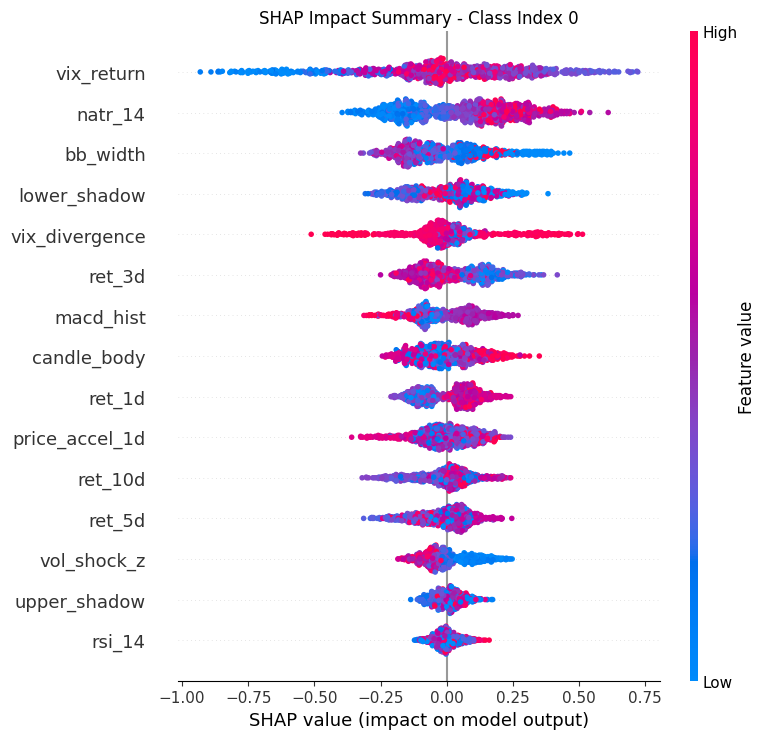

In [9]:
explainer = ShapExplainer()
shap_df, shap_fig = explainer.generate_diagnostics(final_model, train_panel)
print("\nTop 5 Drivers (SHAP Mean Impact):")
print(shap_df.head(5))

In [10]:
tracker = QuantTracker(experiment_name="MultiTicker_WalkForward")
tracker.log_walk_forward_run(
    run_name="Baseline Production Model",
    model_params=lgbm_params,
    y_true=res_df['y_true'].values,
    y_pred=res_df['y_pred'].values,
    train_days=252,
    step_days=20,
    q_high=q_high_val,
    q_low=q_low_val,
    buy_threshold=buy_thresh,
    sell_threshold=sell_thresh,
    final_model=final_model,
    permutation_metrics=shuffle_metrics,
    shap_fig=shap_fig,   
    shap_df=shap_df,
    financial_metrics=fin_metrics,
    loo_metrics=loo_metrics
)

Run 'Baseline Production Model' successfully committed to MLflow registry.
🏃 View run Baseline Production Model at: http://localhost:5000/#/experiments/5/runs/a56edda0b84940efb6dda1f11112c295
🧪 View experiment at: http://localhost:5000/#/experiments/5


In [11]:
target_maker = TargetEngineer(q_high=q_high_val, q_low=q_low_val)
target_maker.fit_transform(train_panel)

exporter = ProductionExporter(export_dir="../models/etf/production")
exporter.export(
    model=final_model,
    target_engineer=target_maker,
    buy_threshold=buy_thresh,
    sell_threshold=sell_thresh,
    train_days=252,
    step_days=20,
    embargo_days=5
)


--- SUCCESSFUL PRODUCTION EXPORT ---
Model saved at: ../models/etf/production/etf_baseline_1.joblib
Manifest saved at: ../models/etf/production/quant_config.json


In [12]:
simulator = OOSQuantSimulator(model_dir="../models/etf/production")
oos_metrics, oos_curve_df = simulator.simulate_portfolio(oos_panel_2026)

print("\n--- PURE OUT-OF-SAMPLE 2026 TEST ---")
print(f"Market Return:      {oos_metrics['Total_Return_Market']*100:.2f}%")
print(f"Strategy Return:    {oos_metrics['Total_Return_Strat']*100:.2f}%")
print(f"Max Drawdown:       {oos_metrics['Max_Drawdown']*100:.2f}%")
print(f"Annual Sharpe:      {oos_metrics['Sharpe_Ratio']:.2f}")

Loading production artifacts...


NameError: name 'oos_panel_2026' is not defined

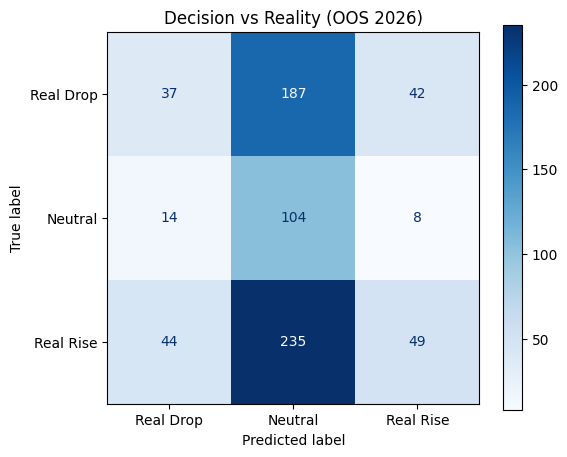

In [ ]:
X_oos = oos_panel_2026[simulator.required_features]
probs_oos = simulator.model.predict_proba(X_oos)
y_pred_oos = np.zeros(len(oos_panel_2026))

idx_buy = np.where(simulator.model.classes_ == 1)[0][0]
idx_sell = np.where(simulator.model.classes_ == -1)[0][0]
y_pred_oos[probs_oos[:, idx_buy] >= simulator.buy_threshold] = 1
y_pred_oos[probs_oos[:, idx_sell] >= simulator.sell_threshold] = -1

y_true_real = np.zeros(len(oos_panel_2026))
y_true_real[oos_panel_2026['fwd_log_return'] > 0.002] = 1
y_true_real[oos_panel_2026['fwd_log_return'] < -0.002] = -1

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true_real, y_pred_oos, labels=[-1, 0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real Drop", "Neutral", "Real Rise"])
disp.plot(ax=ax, cmap='Blues')
plt.title("Decision vs Reality (OOS 2026)")
plt.show()